In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule

In [2]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='36', run_id='cfc7077d9f4542eb9c3f6f415ae20a04')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1586.)
  tensor = torch.frombuffer(


Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:36//data/model.pt2


In [3]:
model.predict(torch.randn(1,3,512,256))

(17.334028244018555,
 tensor([[[0.0015, 0.0013, 0.0015,  ..., 0.0008, 0.0010, 0.0011],
          [0.0020, 0.0021, 0.0026,  ..., 0.0018, 0.0012, 0.0015],
          [0.0024, 0.0018, 0.0028,  ..., 0.0016, 0.0016, 0.0015],
          ...,
          [0.0007, 0.0005, 0.0007,  ..., 0.0009, 0.0010, 0.0008],
          [0.0005, 0.0004, 0.0005,  ..., 0.0007, 0.0005, 0.0007],
          [0.0004, 0.0005, 0.0007,  ..., 0.0008, 0.0006, 0.0005]]],
        device='cuda:0'))

In [4]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='fit')

In [5]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=2)
sample.shape

torch.Size([1, 3, 672, 1024])

In [6]:
result_count, result  = model.predict(sample)
(result_count, result)

(305.3935546875,
 tensor([[[4.5874e-04, 3.2416e-04, 5.3323e-04,  ..., 1.4052e-04,
           3.9274e-04, 7.4589e-04],
          [3.5127e-04, 1.7362e-04, 2.3303e-04,  ..., 8.0567e-05,
           1.5130e-04, 3.1304e-04],
          [3.4522e-04, 2.8556e-04, 2.3304e-04,  ..., 1.2427e-04,
           1.9065e-04, 2.3885e-04],
          ...,
          [3.4206e-04, 1.0997e-04, 1.2706e-04,  ..., 2.1395e-04,
           2.6950e-04, 4.8249e-04],
          [3.3522e-04, 9.8529e-05, 1.6443e-04,  ..., 2.3406e-04,
           2.6921e-04, 3.4266e-04],
          [4.2440e-04, 4.1676e-04, 4.6638e-04,  ..., 4.7750e-04,
           5.3694e-04, 4.1471e-04]]], device='cuda:0'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


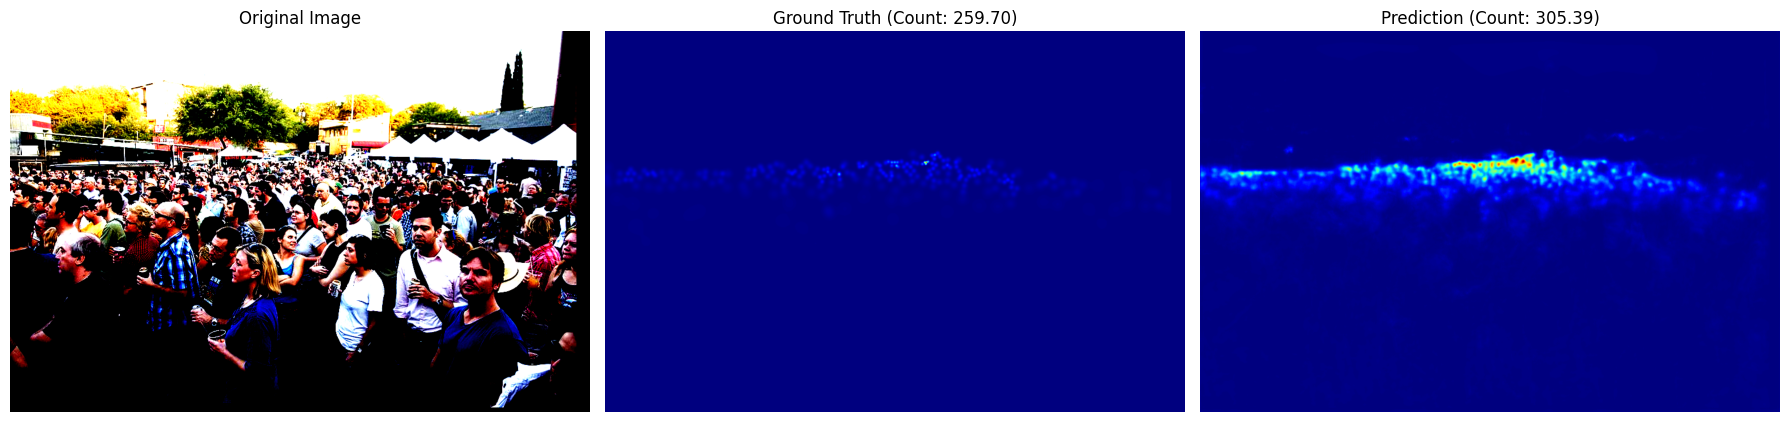

In [7]:
vis.visualize_sample(sample, target, result, count, result_count, )

In [9]:
from src.models.model import CrowdCounter


crowd_model = CrowdCounter(params=params)
# crowd_model.load_state_dict(model.model.state_dict())
crowd_model.eval()

CrowdCounter(
  (net): UNet(
    (net): Unet(
      (encoder): EfficientNetEncoder(
        (_conv_stem): Conv2dStaticSamePadding(
          3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
          (static_padding): ZeroPad2d((0, 1, 0, 1))
        )
        (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_blocks): ModuleList(
          (0): MBConvBlock(
            (_expand_conv): Identity()
            (_bn0): Identity()
            (_depthwise_conv): Conv2dStaticSamePadding(
              32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
              (static_padding): ZeroPad2d((1, 1, 1, 1))
            )
            (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
            (_se_reduce): Conv2dStaticSamePadding(
              32, 8, kernel_size=(1, 1), stride=(1, 1)
              (static_padding): Identity()
            )
            (_se_

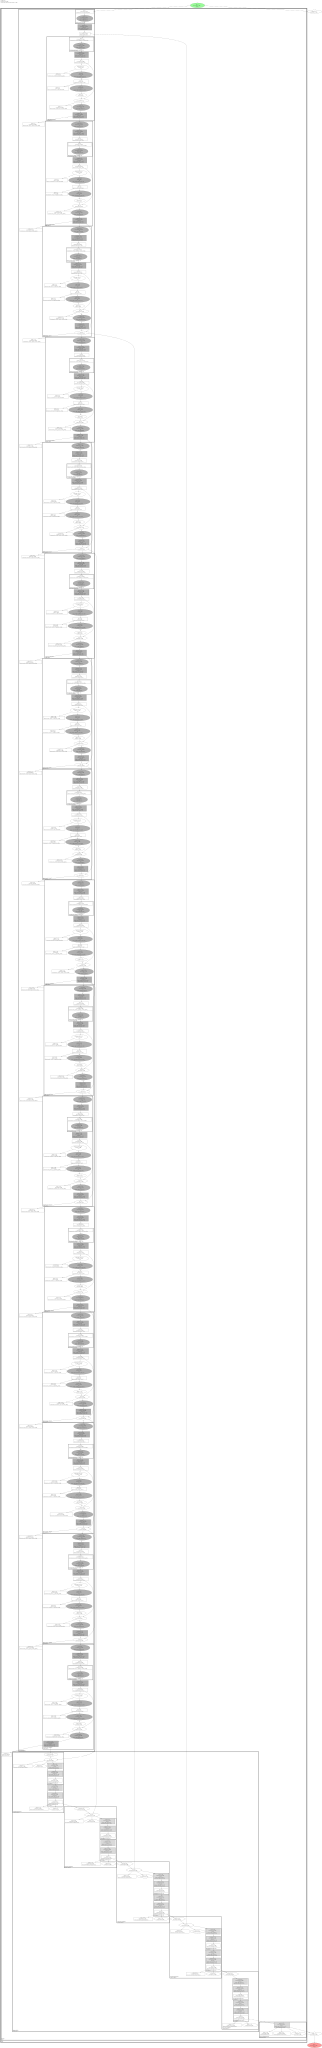

[Errno 2] No such file or directory: 'xdg-open'


In [11]:
vis.visualize_model_graph(crowd_model, sample=sample)